In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the Dataset.
Insu = pd.read_csv("MedicalCost/insurance.csv")

# First 5 rows.
print(f"The first 5 columns:{Insu.head()}")

The first 5 columns:   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
# Number of rows and columns.
print(f"Number of rows & columns:{Insu.shape}")

Number of rows & columns:(1338, 7)


In [ ]:
# Inspecting Dataset with ".info".
print(f"datatypes:{Insu.info()}")

# Turning 3 columns into categorical ones for optimization that will help in phase 2.
Insu["sex"] = Insu["sex"].astype("category")
Insu["smoker"] = Insu["smoker"].astype("category")
Insu["region"] = Insu["region"].astype("category")

# Checking if they successfully changed or not.
print(f"datatypes:{Insu.info()}")

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
datatypes:None
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1338 non-null   int64   
 1   sex       1338 non-null   category
 2   bmi       1338 non-null   float64 
 3   children  1338 non-null   int64   
 4   smoker    1338 non-null   category
 5   region    1338 non-null   category
 6   charges   1338 non-null   float64 
dtypes: category(3), floa

In [ ]:
# Find missing values.
Insumiss = Insu.isnull() 
print(f"Missing values:{Insumiss.sum}")
# No missing values found.

Missing values:<bound method DataFrame.sum of         age    sex    bmi  children  smoker  region  charges
0     False  False  False     False   False   False    False
1     False  False  False     False   False   False    False
2     False  False  False     False   False   False    False
3     False  False  False     False   False   False    False
4     False  False  False     False   False   False    False
...     ...    ...    ...       ...     ...     ...      ...
1333  False  False  False     False   False   False    False
1334  False  False  False     False   False   False    False
1335  False  False  False     False   False   False    False
1336  False  False  False     False   False   False    False
1337  False  False  False     False   False   False    False

[1338 rows x 7 columns]>


In [ ]:
# Handling duplicates.
Insudupli = Insu.duplicated()
print(f"Duplicates:{Insudupli.sum()}")
# 1 Duplicated row found, let's remove it.
Insu = Insu.drop_duplicates()
Insudupli = Insu.duplicated()
print(f"Duplicates after removal:{Insudupli.sum()}")

Duplicates:1
Duplicates after removal:0


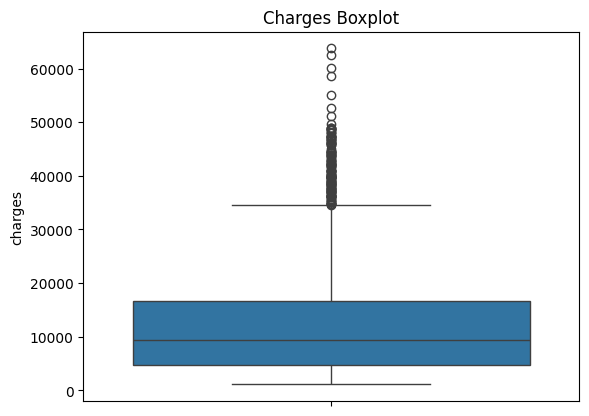

In [ ]:
# Show boxplot to detect outliers in charges.
sns.boxplot(Insu["charges"])
plt.title("Charges Boxplot")
plt.show()

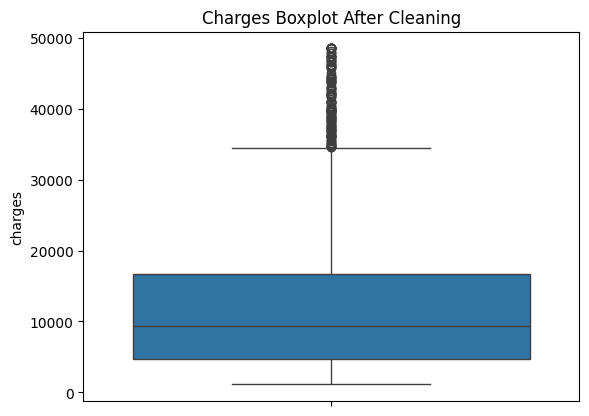

In [ ]:
# Get the 99th percentile value.
VALUE = Insu["charges"].quantile(0.99)

# Cap values above the 99th percentile.
Insu["charges"] = Insu["charges"].clip(upper=VALUE)

# Show boxplot after capping outliers.
sns.boxplot(Insu["charges"])
plt.title("Charges Boxplot After Cleaning")
plt.show()

The first 5 columns:   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Number of rows & columns:(1338, 7)
<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1337 non-null   int64   
 1   sex       1337 non-null   category
 2   bmi       1337 non-null   float64 
 3   children  1337 non-null   int64   
 4   smoker    1337 non-null   category
 5   region    1337 non-null   category
 6   charges   1337 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 56.2 KB
datatypes:None
<class 'pandas.DataFrame'>
Index

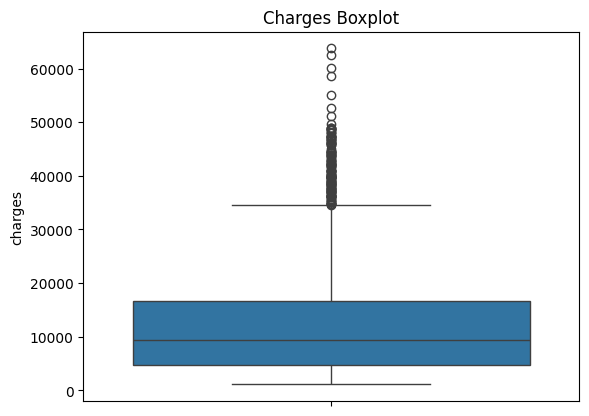

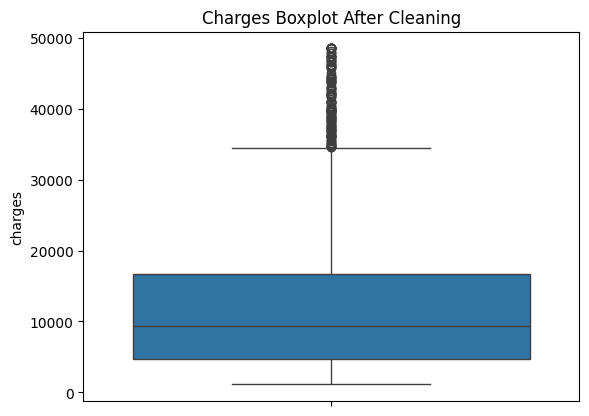

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1337 rows x 7 columns]
Missing values: 0
Invalid charges: 0
Dataset shape: (1337, 7)


In [ ]:
# Defining a function with the steps in all of the cells above. 
def clean_dataset(df): 

    data = pd.read_csv(df)

    print(f"The first 5 columns:{data.head()}")
    
    print(f"Number of rows & columns:{data.shape}")

    print(f"datatypes:{Insu.info()}")

    Insu["sex"] = Insu["sex"].astype("category")
    Insu["smoker"] = Insu["smoker"].astype("category")
    Insu["region"] = Insu["region"].astype("category")

    print(f"datatypes:{Insu.info()}")

    datamiss = data.isnull() 
    print(f"Missing values:{datamiss.sum}")

    datadupli = data.duplicated()
    print(f"Duplicates:{datadupli.sum()}")
    
    data = data.drop_duplicates()
    datadupli = data.duplicated()
    print(f"Duplicates after removal:{datadupli.sum()}")

    sns.boxplot(data["charges"])
    plt.title("Charges Boxplot")
    plt.show()

    VALUE = data["charges"].quantile(0.99)

    data["charges"] = data["charges"].clip(upper=VALUE)

    sns.boxplot(data["charges"])
    plt.title("Charges Boxplot After Cleaning")
    plt.show()

    return data


# Calling the function.
Insu = clean_dataset("MedicalCost/insurance.csv")

# Printing the output of the function.
print(Insu)

# Final 3 checks:

# Check 1: no missing values remain.
print("Missing values:", Insu.isnull().sum().sum())

# Check 2: charges are valid (> 0).
print("Invalid charges:", (Insu["charges"] <= 0).sum())

# Check 3: confirm dataset shape.
print("Dataset shape:", Insu.shape)